In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import os

print(os.getcwd())
print(os.listdir("C:\MetroFlow\dataset"))

C:\MetroFlow\EDA
['delhi_metro_updated.csv']


In [8]:
df = pd.read_csv("C:\MetroFlow\dataset\delhi_metro_updated.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [9]:
df.head()


,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,08-05-2022,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,12-01-2023,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,13-07-2023,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,10-11-2022,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,06-11-2022,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


In [10]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(150000, 10)


In [11]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare',
       'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks'],
      dtype='str')


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  str    
 2   From_Station        150000 non-null  str    
 3   To_Station          150000 non-null  str    
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  str    
 9   Remarks             123743 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 18.8 MB


In [13]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
TripID                    0
Date                      0
From_Station              0
To_Station                0
Distance_km               0
Fare                      0
Cost_per_passenger        0
Passengers             1500
Ticket_Type            1500
Remarks               26257
dtype: int64


In [14]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [15]:
df.describe()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,150000.000000,150000.000000,150000.000000,150000.000000,148500.000000
mean,75000.500000,5.490446,105.116503,62.474807,20.003522
std,43301.414527,4.980333,54.879494,33.207161,4.468134
min,1.000000,0.500000,10.000000,5.000000,4.000000
25%,37500.750000,1.940000,57.570000,33.687500,17.000000
50%,75000.500000,3.960000,105.170000,62.520000,20.000000
75%,112500.250000,7.420000,152.572500,91.190000,23.000000
max,150000.000000,63.030000,200.000000,120.000000,41.000000


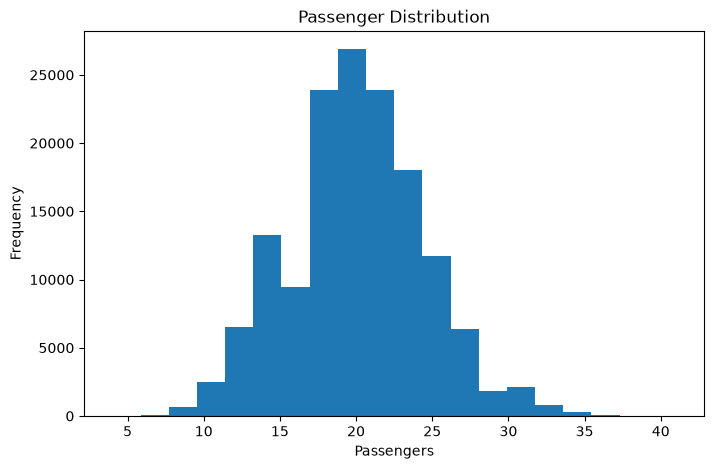

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["Passengers"].dropna(), bins=20)

plt.title("Passenger Distribution")
plt.xlabel("Passengers")
plt.ylabel("Frequency")

plt.show()

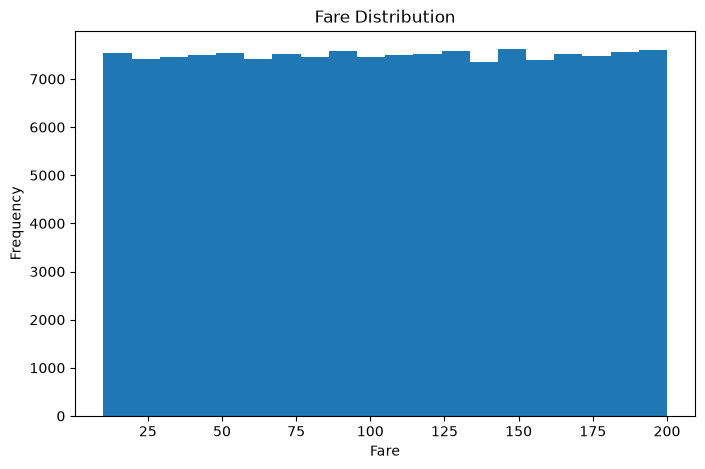

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

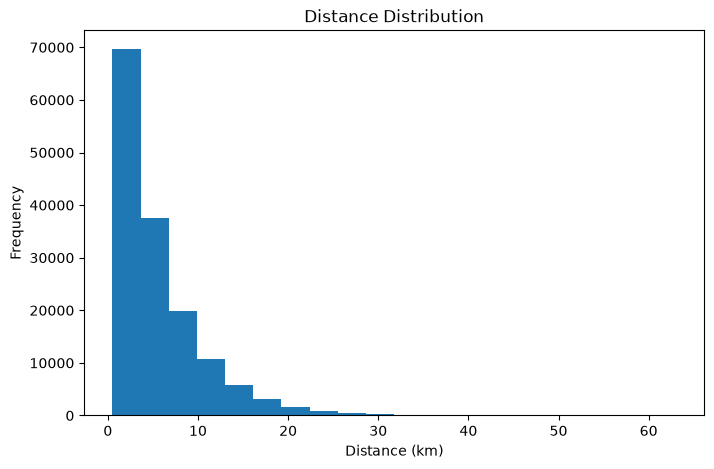

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["Distance_km"], bins=20)

plt.title("Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")

plt.show()

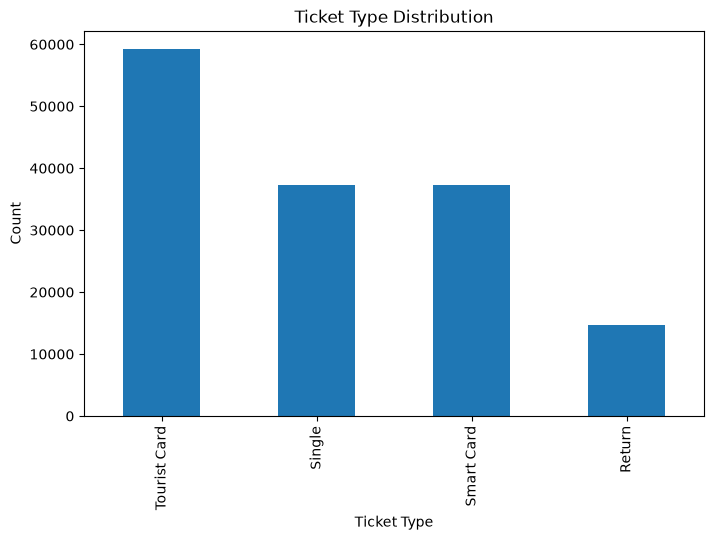

In [19]:
plt.figure(figsize=(8,5))

df["Ticket_Type"].value_counts().plot(kind="bar")

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")

plt.show()

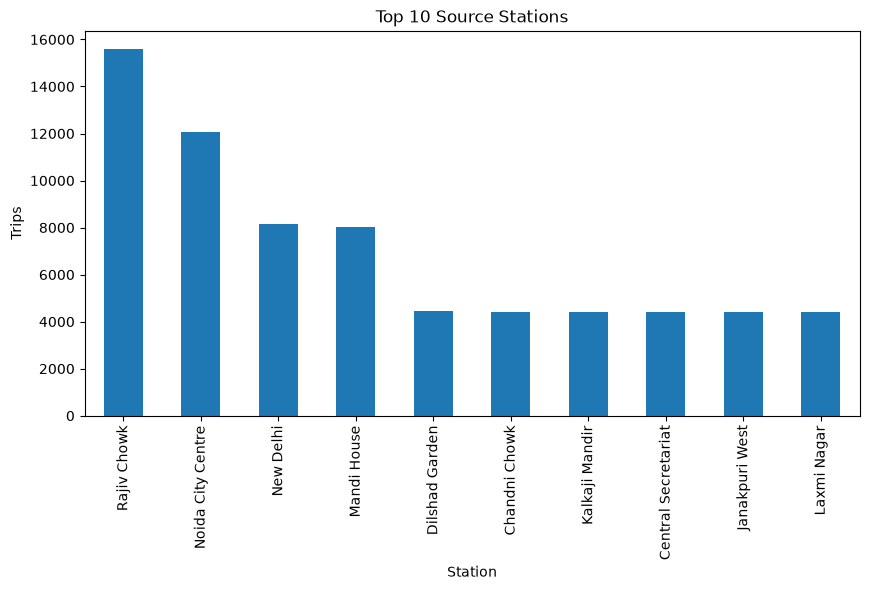

In [20]:
plt.figure(figsize=(10,5))

df["From_Station"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Source Stations")
plt.xlabel("Station")
plt.ylabel("Trips")

plt.show()

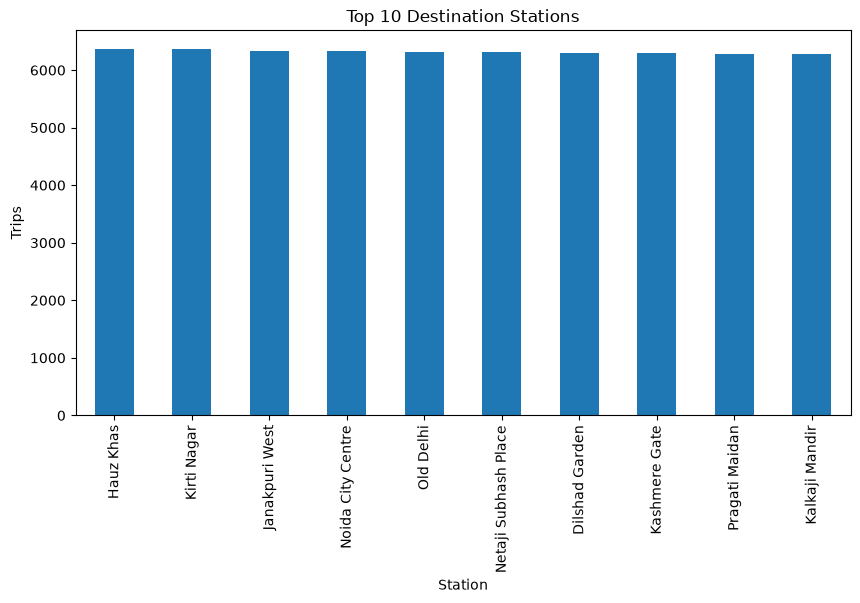

In [21]:
plt.figure(figsize=(10,5))

df["To_Station"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Destination Stations")
plt.xlabel("Station")
plt.ylabel("Trips")

plt.show()

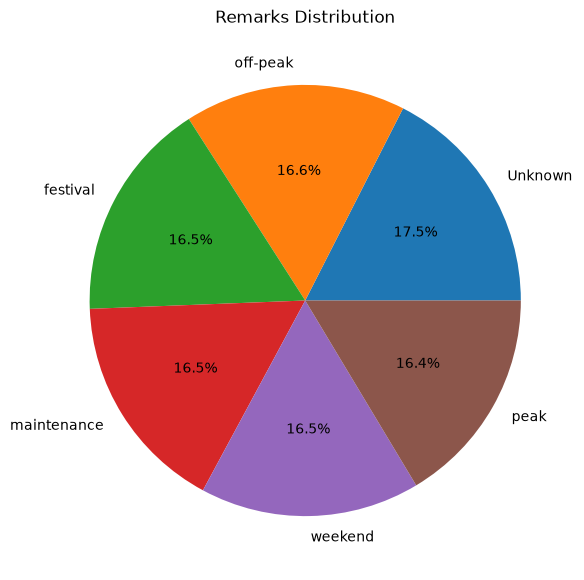

In [22]:
plt.figure(figsize=(7,7))

df["Remarks"].fillna("Unknown").value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Remarks Distribution")

plt.show()

In [23]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
TripID,1.000000,0.001066,-0.000817,0.000205,0.003067
Distance_km,0.001066,1.000000,0.000646,-0.000794,-0.001730
Fare,-0.000817,0.000646,1.000000,-0.003351,-0.000490
Cost_per_passenger,0.000205,-0.000794,-0.003351,1.000000,-0.000560
Passengers,0.003067,-0.001730,-0.000490,-0.000560,1.000000


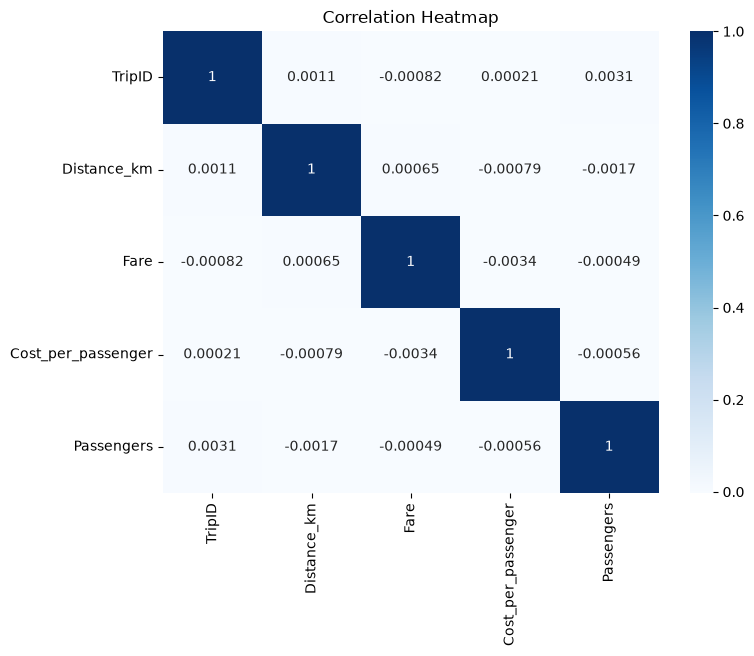

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

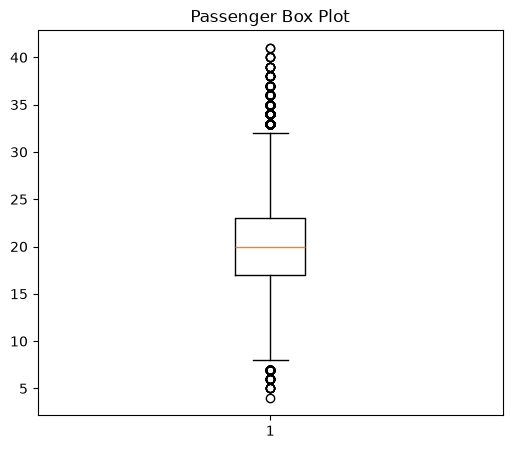

In [25]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Passengers"].dropna())

plt.title("Passenger Box Plot")

plt.show()